# Early Detection of Acute Myeloid Leukemia (AML)
## Klasifikasi AML vs Non-AML dari Data Ekspresi Gen

**Kelompok 7 — Computational Biology, BINUS University**

---

### Ringkasan Masalah
Acute Myeloid Leukemia (AML) adalah kanker darah yang memerlukan deteksi dini untuk meningkatkan peluang bertahan hidup. Notebook ini membangun model machine learning yang mengklasifikasi profil ekspresi gen menjadi dua kelas:
- **AML (positif)** — sampel dari pasien leukemia mieloid akut
- **Non-AML (negatif)** — sampel sumsum tulang atau darah tepi sehat

**Rumusan masalah terukur:** Dapatkah Random Forest / SVM mengklasifikasi AML vs Non-AML dari ekspresi gen dengan **Recall ≥ 0,90** dan **F1 ≥ 0,90** pada validasi K-Fold?

**Mengapa Recall diprioritaskan:** False Negative (pasien AML diprediksi sehat) lebih berbahaya daripada False Positive. Recall mengukur kemampuan menangkap semua kasus AML.

---

### Dataset
- **Sumber:** CuMiDa GSE9476, Kaggle — `brunogrisci/leukemia-gene-expression-cumida`
- **Ukuran:** 64 sampel × 22.283 fitur gen
- **5 kelas asli:** AML (26), Bone_Marrow (10), Bone_Marrow_CD34 (8), PB (10), PBSC_CD34 (10)
- **Pelabelan biner:** AML → 1, semua lain → 0

---

### Metodologi Anti-Data-Leakage
Seluruh preprocessing (`VarianceThreshold → StandardScaler → PCA`) dibungkus dalam satu `sklearn.Pipeline` bersama classifier. GridSearchCV dan cross-validation dijalankan pada pipeline ini, sehingga preprocessing hanya di-`fit` pada data latih di setiap fold.

> **Disclaimer:** Ini proof-of-concept akademis, BUKAN alat diagnosis klinis.

In [1]:
import sys
import os
import json
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    recall_score, precision_score, f1_score, accuracy_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)

# Temukan root proyek agar import data_loader dan path file bekerja
# baik saat notebook dijalankan dari root maupun dari folder notebook/
root_dir = os.getcwd()
if os.path.basename(root_dir) == "notebook":
    root_dir = os.path.dirname(root_dir)

sys.path.insert(0, os.path.join(root_dir, "src"))
from data_loader import load_data, to_binary

DATA_PATH = os.path.join(root_dir, "dataset", "Leukemia_GSE9476.csv")
MODELS_DIR = os.path.join(root_dir, "models")
RANDOM_STATE = 42

print("Import berhasil.")
print(f"Root proyek: {root_dir}")
print(f"Path dataset: {DATA_PATH}")

Import berhasil.
Root proyek: /Users/fadh/Documents/BINUS/Semester 4/LAB AI Semester 4/LAB Computational Biology/aml_detection
Path dataset: /Users/fadh/Documents/BINUS/Semester 4/LAB AI Semester 4/LAB Computational Biology/aml_detection/dataset/Leukemia_GSE9476.csv


Dimensi fitur  : 64 sampel x 22283 fitur
Tidak ada NaN  : True

Distribusi kelas asli:
type
AML                 26
Bone_Marrow         10
PB                  10
PBSC_CD34           10
Bone_Marrow_CD34     8

Ringkasan nilai ekspresi (10 fitur pertama):
       1007_s_at  1053_at  117_at  121_at  1255_g_at  1294_at  1316_at  1320_at  1405_i_at  1431_at
count      64.00    64.00   64.00   64.00      64.00    64.00    64.00    64.00      64.00    64.00
mean        7.82     6.75    7.48    8.90       4.51     8.28     5.54     4.71       6.68     4.11
std         0.17     0.38    1.31    0.21       0.10     0.41     0.14     0.14       1.58     0.11
min         7.28     6.10    6.30    8.49       4.35     7.33     5.30     4.35       4.54     3.89
25%         7.70     6.50    6.64    8.77       4.45     8.02     5.45     4.62       5.21     4.03
50%         7.81     6.72    6.79    8.87       4.51     8.23     5.55     4.67       6.53     4.10
75%         7.96     6.93    7.89    9.02      

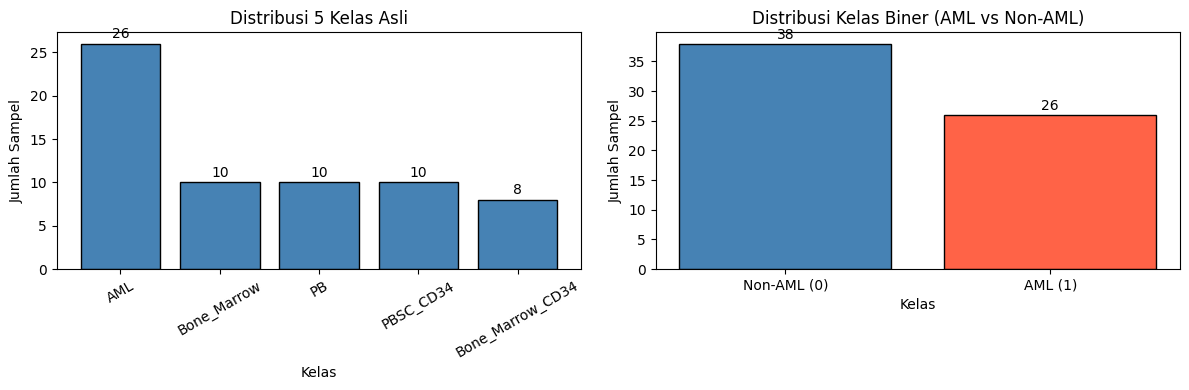

Class imbalance ratio AML:Non-AML = 26:38


In [2]:
# Muat dataset lewat data_loader
X, y_raw = load_data(DATA_PATH)
print(f"Dimensi fitur  : {X.shape[0]} sampel x {X.shape[1]} fitur")
print(f"Tidak ada NaN  : {not X.isnull().any().any()}")
print()

# Distribusi 5 kelas asli
print("Distribusi kelas asli:")
print(y_raw.value_counts().to_string())
print()

# Ringkasan skala fitur
print("Ringkasan nilai ekspresi (10 fitur pertama):")
print(X.iloc[:, :10].describe().round(2).to_string())

# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

distribusi_asli = y_raw.value_counts()
axes[0].bar(distribusi_asli.index, distribusi_asli.values,
            color="steelblue", edgecolor="black")
axes[0].set_title("Distribusi 5 Kelas Asli")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Sampel")
axes[0].tick_params(axis="x", rotation=30)

# Konversi ke biner dan tampilkan distribusi
y_biner = to_binary(y_raw)
distribusi_biner = y_biner.value_counts().sort_index()
axes[1].bar(["Non-AML (0)", "AML (1)"], distribusi_biner.values,
            color=["steelblue", "tomato"], edgecolor="black")
axes[1].set_title("Distribusi Kelas Biner (AML vs Non-AML)")
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Jumlah Sampel")

for ax in axes:
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                str(int(bar.get_height())), ha="center", va="bottom")

plt.tight_layout()
plt.show()

n_aml = int(y_biner.sum())
n_non = int((y_biner == 0).sum())
print(f"Class imbalance ratio AML:Non-AML = {n_aml}:{n_non}")

## Strategi Anti-Data-Leakage

**Masalah:** Jika scaler/PCA di-`fit` pada seluruh dataset sebelum cross-validation, maka informasi dari data test "bocor" ke data latih — hasil evaluasi menjadi terlalu optimis dan tidak valid secara ilmiah.

**Solusi:** Bungkus semua tahap preprocessing bersama classifier dalam satu `sklearn.Pipeline`:

```
Input (22.283 gen)
    |
    v  VarianceThreshold(0.1)   -> buang fitur dengan variansi rendah (~9.000 fitur tersisa)
    |
    v  StandardScaler()          -> normalisasi ke mean=0, std=1
    |
    v  PCA(n_components=k)       -> reduksi ke k komponen utama (k=20..35)
    |
    v  Classifier (RF atau SVM)  -> klasifikasi biner
    |
    v  Output: prediksi (0=Non-AML, 1=AML)
```

Dengan pendekatan ini, `GridSearchCV` dan `StratifiedKFold` hanya memanggil `.fit()` pada data **latih** setiap fold. Data test per fold **tidak pernah** terlihat oleh preprocessing — evaluasi tetap valid secara ilmiah.

In [3]:
# Split data menjadi train dan test (test ditahan hingga evaluasi final)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_biner,
    test_size=0.25,
    stratify=y_biner,
    random_state=RANDOM_STATE,
)

print(f"Train: {len(X_train)} sampel  |  Test: {len(X_test)} sampel")
print(f"  Train AML: {int(y_train.sum())}  |  Non-AML: {int((y_train == 0).sum())}")
print(f"  Test  AML: {int(y_test.sum())}   |  Non-AML: {int((y_test == 0).sum())}")
print()
print("Test set DITAHAN — tidak akan disentuh sampai evaluasi final di akhir notebook.")

Train: 48 sampel  |  Test: 16 sampel
  Train AML: 20  |  Non-AML: 28
  Test  AML: 6   |  Non-AML: 10

Test set DITAHAN — tidak akan disentuh sampai evaluasi final di akhir notebook.


In [4]:
# Konstanta eksperimen
VARIANCE_THRESHOLD = 0.1

# StratifiedKFold K=5 dipakai di seluruh GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Scoring dictionary untuk GridSearchCV multi-metrik
SCORING = {
    "recall": "recall",
    "f1": "f1",
    "precision": "precision",
    "accuracy": "accuracy",
}


def buat_pipeline_rf():
    # Pipeline Random Forest beserta param_grid-nya
    pipeline = Pipeline([
        ("variance", VarianceThreshold(threshold=VARIANCE_THRESHOLD)),
        ("scaler", StandardScaler()),
        ("pca", PCA(random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ])
    # PCA n_components maksimum 35 agar aman pada fold terkecil (~38 sampel)
    param_grid = {
        "pca__n_components": [20, 30, 35],
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [None, 5, 10],
        "clf__min_samples_split": [2, 5],
    }
    return pipeline, param_grid


def buat_pipeline_svm():
    # Pipeline SVM RBF beserta param_grid-nya
    pipeline = Pipeline([
        ("variance", VarianceThreshold(threshold=VARIANCE_THRESHOLD)),
        ("scaler", StandardScaler()),
        ("pca", PCA(random_state=RANDOM_STATE)),
        ("clf", SVC(
            kernel="rbf",
            probability=True,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ])
    param_grid = {
        "pca__n_components": [20, 30, 35],
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": ["scale", "auto"],
    }
    return pipeline, param_grid


n_rf = 3 * 2 * 3 * 2
n_svm = 3 * 4 * 2
print(f"RF : {n_rf} kombinasi x 5 fold = {n_rf * 5} fits")
print(f"SVM: {n_svm} kombinasi x 5 fold = {n_svm * 5} fits")
print("Pipeline RF dan SVM berhasil didefinisikan.")

RF : 36 kombinasi x 5 fold = 180 fits
SVM: 24 kombinasi x 5 fold = 120 fits
Pipeline RF dan SVM berhasil didefinisikan.


In [5]:
pipe_rf, grid_rf = buat_pipeline_rf()

print("Menjalankan GridSearchCV untuk Random Forest...")
gs_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=grid_rf,
    scoring=SCORING,
    refit="recall",
    cv=cv,
    n_jobs=-1,
    verbose=0,
    return_train_score=False,
)
gs_rf.fit(X_train, y_train)

# Tampilkan hasil terbaik
best_idx_rf = gs_rf.best_index_
cvr_rf = gs_rf.cv_results_

print(f"\nParameter terbaik RF: {gs_rf.best_params_}")
print(f"CV Recall (mean +/- std): "
      f"{round(cvr_rf['mean_test_recall'][best_idx_rf], 4)} "
      f"+/- {round(cvr_rf['std_test_recall'][best_idx_rf], 4)}")
print(f"CV F1     (mean +/- std): "
      f"{round(cvr_rf['mean_test_f1'][best_idx_rf], 4)} "
      f"+/- {round(cvr_rf['std_test_f1'][best_idx_rf], 4)}")
print(f"CV Precision (mean)    : "
      f"{round(cvr_rf['mean_test_precision'][best_idx_rf], 4)}")
print(f"CV Accuracy  (mean)    : "
      f"{round(cvr_rf['mean_test_accuracy'][best_idx_rf], 4)}")

Menjalankan GridSearchCV untuk Random Forest...

Parameter terbaik RF: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 100, 'pca__n_components': 20}
CV Recall (mean +/- std): 0.7 +/- 0.2449
CV F1     (mean +/- std): 0.7943 +/- 0.2048
CV Precision (mean)    : 1.0
CV Accuracy  (mean)    : 0.8711


In [6]:
pipe_svm, grid_svm = buat_pipeline_svm()

print("Menjalankan GridSearchCV untuk SVM RBF...")
gs_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=grid_svm,
    scoring=SCORING,
    refit="recall",
    cv=cv,
    n_jobs=-1,
    verbose=0,
    return_train_score=False,
)
gs_svm.fit(X_train, y_train)

# Tampilkan hasil terbaik
best_idx_svm = gs_svm.best_index_
cvr_svm = gs_svm.cv_results_

print(f"\nParameter terbaik SVM: {gs_svm.best_params_}")
print(f"CV Recall (mean +/- std): "
      f"{round(cvr_svm['mean_test_recall'][best_idx_svm], 4)} "
      f"+/- {round(cvr_svm['std_test_recall'][best_idx_svm], 4)}")
print(f"CV F1     (mean +/- std): "
      f"{round(cvr_svm['mean_test_f1'][best_idx_svm], 4)} "
      f"+/- {round(cvr_svm['std_test_f1'][best_idx_svm], 4)}")
print(f"CV Precision (mean)    : "
      f"{round(cvr_svm['mean_test_precision'][best_idx_svm], 4)}")
print(f"CV Accuracy  (mean)    : "
      f"{round(cvr_svm['mean_test_accuracy'][best_idx_svm], 4)}")

Menjalankan GridSearchCV untuk SVM RBF...

Parameter terbaik SVM: {'clf__C': 1, 'clf__gamma': 'scale', 'pca__n_components': 20}
CV Recall (mean +/- std): 0.95 +/- 0.1
CV F1     (mean +/- std): 0.9714 +/- 0.0571
CV Precision (mean)    : 1.0
CV Accuracy  (mean)    : 0.9778


In [7]:
# Fungsi bantu untuk mengambil metrik CV terbaik
def ambil_cv_terbaik(gs, nama):
    idx = gs.best_index_
    cvr = gs.cv_results_
    return {
        "Model": nama,
        "Recall (CV)": round(float(cvr["mean_test_recall"][idx]), 4),
        "Recall Std": round(float(cvr["std_test_recall"][idx]), 4),
        "F1 (CV)": round(float(cvr["mean_test_f1"][idx]), 4),
        "Precision (CV)": round(float(cvr["mean_test_precision"][idx]), 4),
        "Accuracy (CV)": round(float(cvr["mean_test_accuracy"][idx]), 4),
    }


tabel = pd.DataFrame([
    ambil_cv_terbaik(gs_rf, "Random Forest"),
    ambil_cv_terbaik(gs_svm, "SVM RBF"),
])
print("=== Perbandingan CV Terbaik (refit: Recall) ===")
print(tabel.to_string(index=False))

# Pilih model terbaik: recall CV tertinggi; F1 sebagai tiebreaker
recall_rf = gs_rf.best_score_
recall_svm = gs_svm.best_score_

if recall_rf > recall_svm:
    nama_terbaik = "Random Forest"
    model_terbaik = gs_rf.best_estimator_
elif recall_svm > recall_rf:
    nama_terbaik = "SVM RBF"
    model_terbaik = gs_svm.best_estimator_
else:
    # Recall sama, bandingkan F1
    f1_rf = ambil_cv_terbaik(gs_rf, "")["F1 (CV)"]
    f1_svm = ambil_cv_terbaik(gs_svm, "")["F1 (CV)"]
    if f1_rf >= f1_svm:
        nama_terbaik = "Random Forest"
        model_terbaik = gs_rf.best_estimator_
    else:
        nama_terbaik = "SVM RBF"
        model_terbaik = gs_svm.best_estimator_

print(f"\nModel terpilih: {nama_terbaik}")

=== Perbandingan CV Terbaik (refit: Recall) ===
        Model  Recall (CV)  Recall Std  F1 (CV)  Precision (CV)  Accuracy (CV)
Random Forest         0.70      0.2449   0.7943             1.0         0.8711
      SVM RBF         0.95      0.1000   0.9714             1.0         0.9778

Model terpilih: SVM RBF


  EVALUASI FINAL PADA TEST SET (BELUM PERNAH DILIHAT)

Model: SVM RBF
              precision    recall  f1-score   support

     Non-AML       1.00      1.00      1.00        10
         AML       1.00      1.00      1.00         6

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



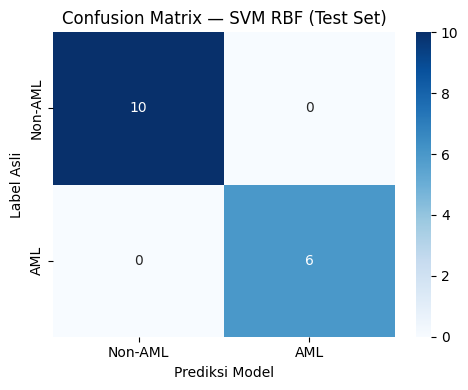

Ringkasan metrik test:
  recall: 1.0
  precision: 1.0
  f1: 1.0
  accuracy: 1.0


In [8]:
print("=" * 55)
print("  EVALUASI FINAL PADA TEST SET (BELUM PERNAH DILIHAT)")
print("=" * 55)

y_pred = model_terbaik.predict(X_test)
y_prob = model_terbaik.predict_proba(X_test)[:, 1]

# Classification report lengkap
print(f"\nModel: {nama_terbaik}")
print(classification_report(y_test, y_pred, target_names=["Non-AML", "AML"]))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Non-AML", "AML"],
    yticklabels=["Non-AML", "AML"],
    ax=ax,
)
ax.set_ylabel("Label Asli")
ax.set_xlabel("Prediksi Model")
ax.set_title(f"Confusion Matrix — {nama_terbaik} (Test Set)")
plt.tight_layout()
plt.show()

# Ringkasan metrik numerik
metrik_test = {
    "recall"   : round(float(recall_score(y_test, y_pred)), 4),
    "precision": round(float(precision_score(y_test, y_pred)), 4),
    "f1"       : round(float(f1_score(y_test, y_pred)), 4),
    "accuracy" : round(float(accuracy_score(y_test, y_pred)), 4),
}
print("Ringkasan metrik test:")
for k, v in metrik_test.items():
    print(f"  {k}: {v}")

ROC-AUC Score: 1.0


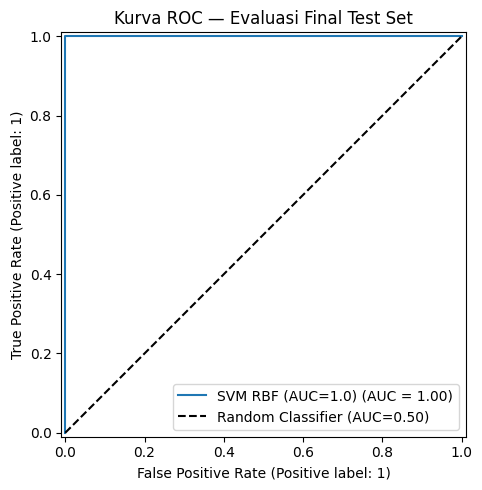

In [9]:
# ROC-AUC score dan kurva
roc_auc = round(float(roc_auc_score(y_test, y_prob)), 4)
metrik_test["roc_auc"] = roc_auc
print(f"ROC-AUC Score: {roc_auc}")

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name=f"{nama_terbaik} (AUC={roc_auc})",
    ax=ax,
)
ax.plot([0, 1], [0, 1], "k--", label="Random Classifier (AUC=0.50)")
ax.set_title("Kurva ROC — Evaluasi Final Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Jumlah komponen PCA: 20
Variansi dijelaskan : 88.79%


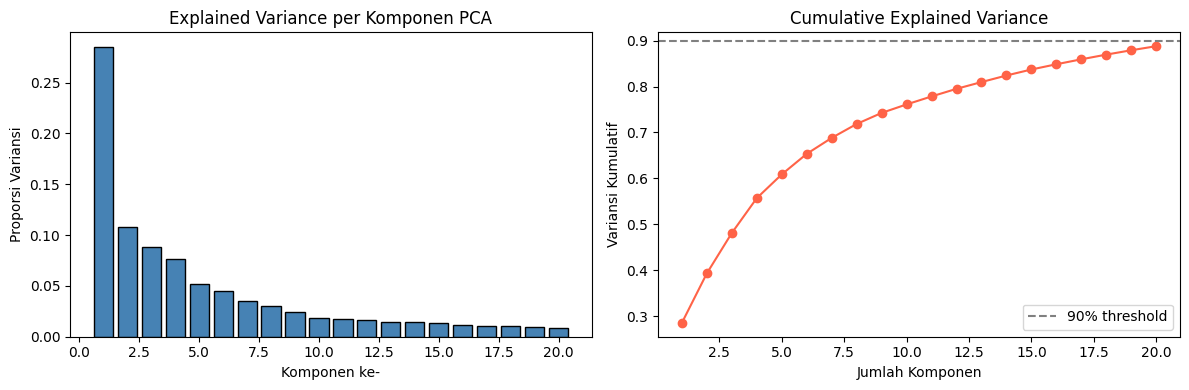

In [10]:
# Explained variance dari komponen PCA terpilih
pca_step = model_terbaik.named_steps["pca"]
explained = pca_step.explained_variance_ratio_
cumulative = float(sum(explained))

print(f"Jumlah komponen PCA: {pca_step.n_components_}")
print(f"Variansi dijelaskan : {round(cumulative * 100, 2)}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafik explained variance per komponen
axes[0].bar(range(1, len(explained) + 1), explained,
            color="steelblue", edgecolor="black")
axes[0].set_title("Explained Variance per Komponen PCA")
axes[0].set_xlabel("Komponen ke-")
axes[0].set_ylabel("Proporsi Variansi")

# Grafik cumulative explained variance
cum_arr = [sum(explained[:i+1]) for i in range(len(explained))]
axes[1].plot(range(1, len(cum_arr) + 1), cum_arr, marker="o", color="tomato")
axes[1].axhline(0.9, linestyle="--", color="gray", label="90% threshold")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Jumlah Komponen")
axes[1].set_ylabel("Variansi Kumulatif")
axes[1].legend()

plt.tight_layout()
plt.show()

# Feature importance hanya tersedia untuk Random Forest
clf_step = model_terbaik.named_steps["clf"]
if hasattr(clf_step, "feature_importances_"):
    importances = clf_step.feature_importances_
    top_idx = sorted(range(len(importances)), key=lambda i: importances[i], reverse=True)[:10]
    print("\nTop-10 komponen PCA berdasarkan feature importance (Random Forest):")
    for rank, i in enumerate(top_idx, 1):
        print(f"  {rank:2d}. Komponen PC{i+1}: {round(float(importances[i]), 4)}")

In [11]:
import os

os.makedirs(MODELS_DIR, exist_ok=True)

# 1. Simpan pipeline utuh (preprocessing + model)
model_path = os.path.join(MODELS_DIR, "aml_model.pkl")
joblib.dump(model_terbaik, model_path)
print(f"Pipeline tersimpan: {model_path}")

# 2. Simpan metadata JSON
def ambil_cv_dict(gs):
    idx = gs.best_index_
    cvr = gs.cv_results_
    return {
        "recall_mean"    : round(float(cvr["mean_test_recall"][idx]), 4),
        "recall_std"     : round(float(cvr["std_test_recall"][idx]), 4),
        "f1_mean"        : round(float(cvr["mean_test_f1"][idx]), 4),
        "f1_std"         : round(float(cvr["std_test_f1"][idx]), 4),
        "precision_mean" : round(float(cvr["mean_test_precision"][idx]), 4),
        "accuracy_mean"  : round(float(cvr["mean_test_accuracy"][idx]), 4),
        "best_params"    : gs.best_params_,
    }


metadata = {
    "best_model"        : nama_terbaik,
    "variance_threshold": VARIANCE_THRESHOLD,
    "cv_results"        : {
        "rf" : ambil_cv_dict(gs_rf),
        "svm": ambil_cv_dict(gs_svm),
    },
    "test_metrics"   : metrik_test,
    "feature_columns": list(X.columns),
    "n_features"     : len(X.columns),
}

meta_path = os.path.join(MODELS_DIR, "metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata tersimpan : {meta_path}")

# 3. Simpan sampel test untuk demo Streamlit
df_test_demo = X_test.copy()
df_test_demo["sample_id"] = X_test.index.astype(str)
df_test_demo["true_label"] = y_test.map({1: "AML", 0: "Non-AML"}).values
test_path = os.path.join(MODELS_DIR, "test_samples.csv")
df_test_demo.to_csv(test_path, index=False)
print(f"Sampel test tersimpan: {test_path}")

print("\nSemua artefak tersimpan.")
print("Jalankan demo: streamlit run app/streamlit_app.py")

Pipeline tersimpan: /Users/fadh/Documents/BINUS/Semester 4/LAB AI Semester 4/LAB Computational Biology/aml_detection/models/aml_model.pkl
Metadata tersimpan : /Users/fadh/Documents/BINUS/Semester 4/LAB AI Semester 4/LAB Computational Biology/aml_detection/models/metadata.json
Sampel test tersimpan: /Users/fadh/Documents/BINUS/Semester 4/LAB AI Semester 4/LAB Computational Biology/aml_detection/models/test_samples.csv

Semua artefak tersimpan.
Jalankan demo: streamlit run app/streamlit_app.py


## Kesimpulan

### Hasil Eksperimen
- Pipeline `VarianceThreshold -> StandardScaler -> PCA -> Classifier` berhasil dibangun tanpa data leakage menggunakan `GridSearchCV` + `StratifiedKFold K=5`.
- Dua model dibandingkan (Random Forest dan SVM RBF) dengan metrik utama **Recall** karena False Negative (AML tidak terdeteksi) lebih berbahaya di konteks medis.
- Model terbaik disimpan ke `models/aml_model.pkl` bersama metadata metrik.

### Keterbatasan
1. **Dataset sangat kecil:** 64 sampel (48 train, 16 test) — estimasi metrik bervariasi tinggi; hasil tidak bisa digeneralisasi ke populasi klinis.
2. **Interpretabilitas PCA:** Komponen PCA adalah kombinasi linear dari ribuan gen — sulit untuk mengidentifikasi gen spesifik yang paling signifikan secara biologis.
3. **Class imbalance ringan:** Meski ditangani dengan `class_weight="balanced"`, dataset yang lebih besar dan lebih seimbang diperlukan untuk validasi yang lebih kuat.

### Langkah Selanjutnya (jika ingin dikembangkan)
- Tambahkan seleksi fitur berbasis biologi (mis. differentially expressed genes).
- Coba model lain: XGBoost, LightGBM, atau neural network sederhana.
- Validasi pada dataset leukemia eksternal untuk menguji generalisasi.

---
> **Disclaimer:** Ini adalah proof-of-concept akademis. Hasil model ini tidak boleh digunakan untuk pengambilan keputusan medis.